# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# Loading Dataset

In [2]:
df = pd.read_csv("heart.csv")

# Understanding the Data 

In [3]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

- sex: 0=Females, 1=Males
- cp: chest pain type
- trestbps: resting blood pressure
- chol: serum cholestrol in mg/dl
- fbs: fasting blood sugar >120mg/dl
- restecg: resting electro-cardiographic results 
- thalach: maximum heart rate achieved
- exang: exercise induced angina
- oldpeak: ST depression induced by exercise relative to rest
- slope: the slope of peak exercise ST segment
- ca: number of major vessels(0-3) colored by flourosopy
- thal: 0=normal; 1=fixed defect; 2=reversible defect
- target: 0=No heart defect, 1=Heart Defect

# Renaming Column Names 

- Let's Rename the columns for better understanding going forward
- We'll use snake_case and make it semantically meaningful

In [5]:
df.rename(columns = {'cp': 'chest_pain', 
                     'trestbps': 'rest_bp', 
                     'fbs': 'fast_blood_sugar', 
                     'restecg': 'rest_ecg',
                     'thalach': 'max_bp',
                     'exang': 'exercise_angina',
                     'oldpeak': 'old_peak',
                     'ca': 'colored_vessels',
                     'thal': 'thallium_heart_rate'
                    }, inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1025 non-null   int64  
 1   sex                  1025 non-null   int64  
 2   chest_pain           1025 non-null   int64  
 3   rest_bp              1025 non-null   int64  
 4   chol                 1025 non-null   int64  
 5   fast_blood_sugar     1025 non-null   int64  
 6   rest_ecg             1025 non-null   int64  
 7   max_bp               1025 non-null   int64  
 8   exercise_angina      1025 non-null   int64  
 9   old_peak             1025 non-null   float64
 10  slope                1025 non-null   int64  
 11  colored_vessels      1025 non-null   int64  
 12  thallium_heart_rate  1025 non-null   int64  
 13  target               1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


- It has no object dtype and no missing values
- Since, it has no object dtype, encoding isn't necessary here

In [7]:
df.shape

(1025, 14)

## Checking for Duplicates 

In [8]:
df.duplicated().sum()

723

In [9]:
df.duplicated().value_counts()

True     723
False    302
dtype: int64

- There are 723 entries that are duplicated

In [10]:
df.drop_duplicates(subset=None, keep='first', inplace = True, ignore_index = False)

- Here keep='first' implies drop all the columns except the first instance 

In [11]:
df.head(3)

,age,sex,chest_pain,rest_bp,chol,fast_blood_sugar,rest_ecg,max_bp,exercise_angina,old_peak,slope,colored_vessels,thallium_heart_rate,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [12]:
df.shape

(302, 14)

In [13]:
for i in df.columns:
    print(f"No. of unique values in {i} is: {df[i].nunique()}")

No. of unique values in age is: 41
No. of unique values in sex is: 2
No. of unique values in chest_pain is: 4
No. of unique values in rest_bp is: 49
No. of unique values in chol is: 152
No. of unique values in fast_blood_sugar is: 2
No. of unique values in rest_ecg is: 3
No. of unique values in max_bp is: 91
No. of unique values in exercise_angina is: 2
No. of unique values in old_peak is: 40
No. of unique values in slope is: 3
No. of unique values in colored_vessels is: 5
No. of unique values in thallium_heart_rate is: 4
No. of unique values in target is: 2


In [14]:
df.describe() # It's a quick statistical overview

,age,sex,chest_pain,rest_bp,chol,fast_blood_sugar,rest_ecg,max_bp,exercise_angina,old_peak,slope,colored_vessels,thallium_heart_rate,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


- In this, we'll be using tree based models, so scaling isn't required

# Splitting Data

In [15]:
X = df.drop(columns = ['target'])
y = df['target']

In [16]:
X

,age,sex,chest_pain,rest_bp,chol,fast_blood_sugar,rest_ecg,max_bp,exercise_angina,old_peak,slope,colored_vessels,thallium_heart_rate
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [17]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

In [18]:
y.info()

<class 'pandas.core.series.Series'>
Int64Index: 302 entries, 0 to 878
Series name: target
Non-Null Count  Dtype
--------------  -----
302 non-null    int64
dtypes: int64(1)
memory usage: 4.7 KB


- y is a 'Series'
- So, we have to convert it to a DataFrame

In [19]:
y = pd.DataFrame(y)

In [20]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
723,1
733,1
739,0
843,0


# Exploratory Data Analysis (EDA)

# Univariate Analysis

## Histograms

- First, let us understand the distribution: Is it skewed, normal, multimodal?

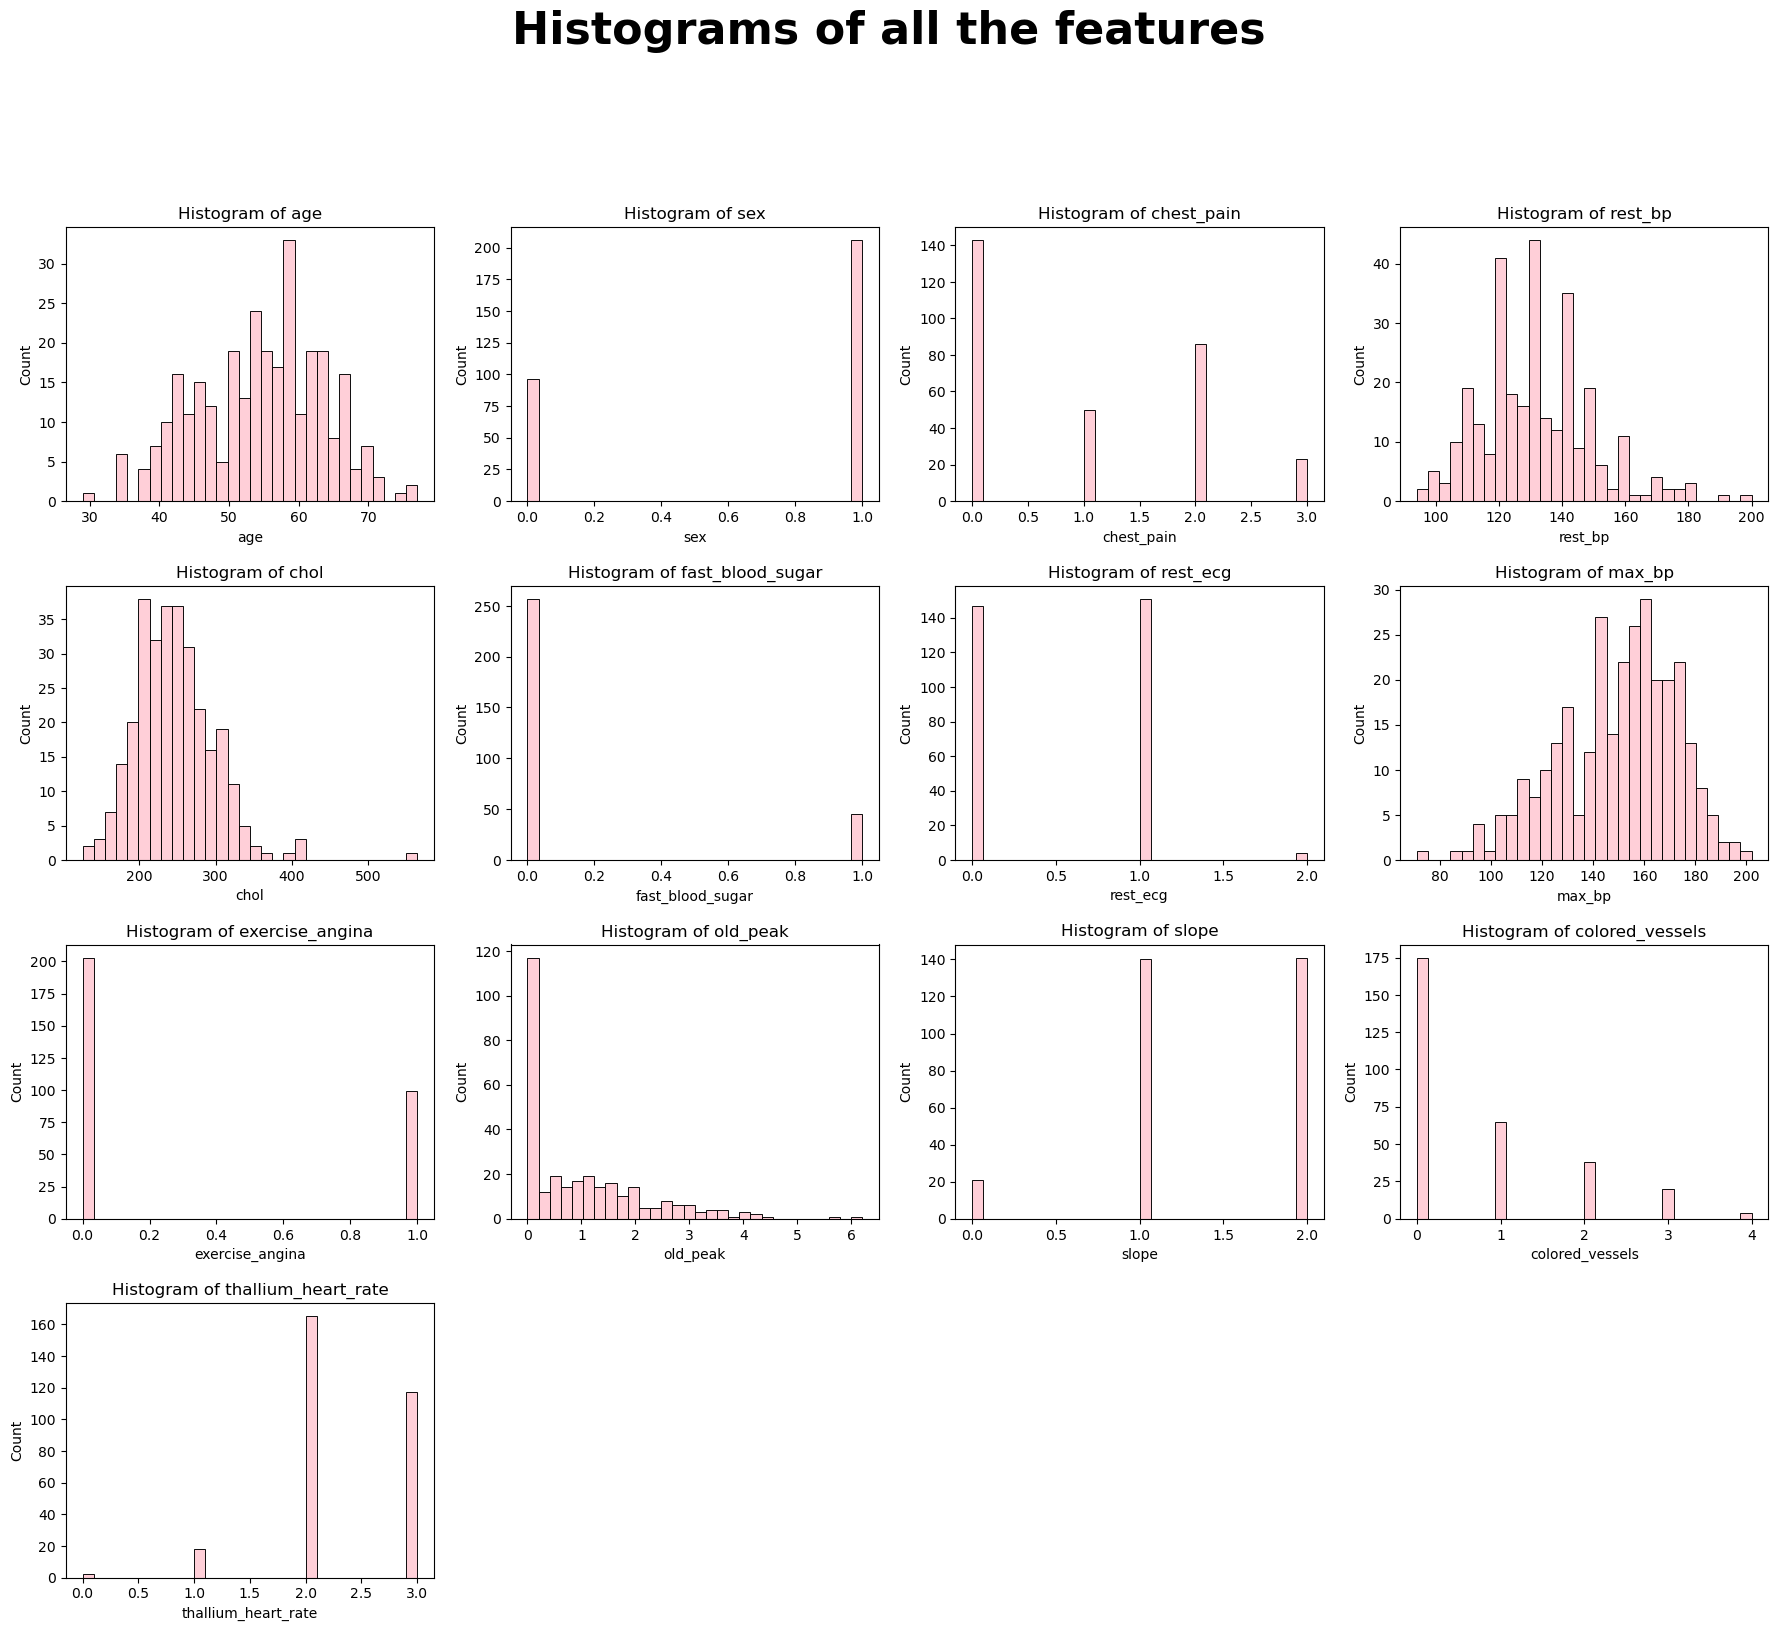

In [21]:
import math 

# Dynamically calculating number of rowns and columns instead of putting 4,4 etc
rows = math.ceil(len(X.columns)/4)

# o/p will have 4 graphs per row
# figsize(x, y): x inches wide, y inches tall
# y*rows: y inches tall per each row
fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

# Set a shared title
fig.suptitle("Histograms of all the features", fontsize = 32, weight = 'bold', y=1.02)

# It converts 2D array of subplots into 1D array for easier indexing
ax = ax.flatten()

# Looping through each feature and its corresponding axis
# enumerate() function returns both the index position i and the feature name at that position
# ax[i] is the position at the subplot grid
for i, feature in enumerate(X):
    sns.histplot(data = X, x = feature, ax = ax[i], bins = 30, kde = False, color = 'pink')
    ax[i].set_title(f"Histogram of {feature}")
    ax[i].set_xlabel(feature)
    
# Loop for hiding unused subplots for aesthetic purposes
# it starts from i+1 i.e the position in the subplot after it iterates through the last feature in the above loop
# axis('off') turns of the axis effectively hiding subplot spaces 
for j in range(i+1, len(ax)):
    ax[j].axis('off')

# plt.tight_layout(rect = [left, bottom, right, top])
# Distance from each edge 
# 0: Edge of the figure, 1: Opposite edge of the figure

plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

1. We can observe Right/Positive skewness in: 
    - rest_bp, chol, fast_blood_sugar, rest_ecg, exercise_angina, old_peak, colores_vessels
    - Most values are relatively low

2. We can observe Left/Negative skewness in:
    - sex, max_bp, slope, thallium_heart_rate
    - Most values are relatively high

3. There is almost very minimal skewness in:
    - age, chest_pain
    - The data is almost evenly distributed around the mean
    - The mean, median, and mode are typically very close to each other

## Box Plots

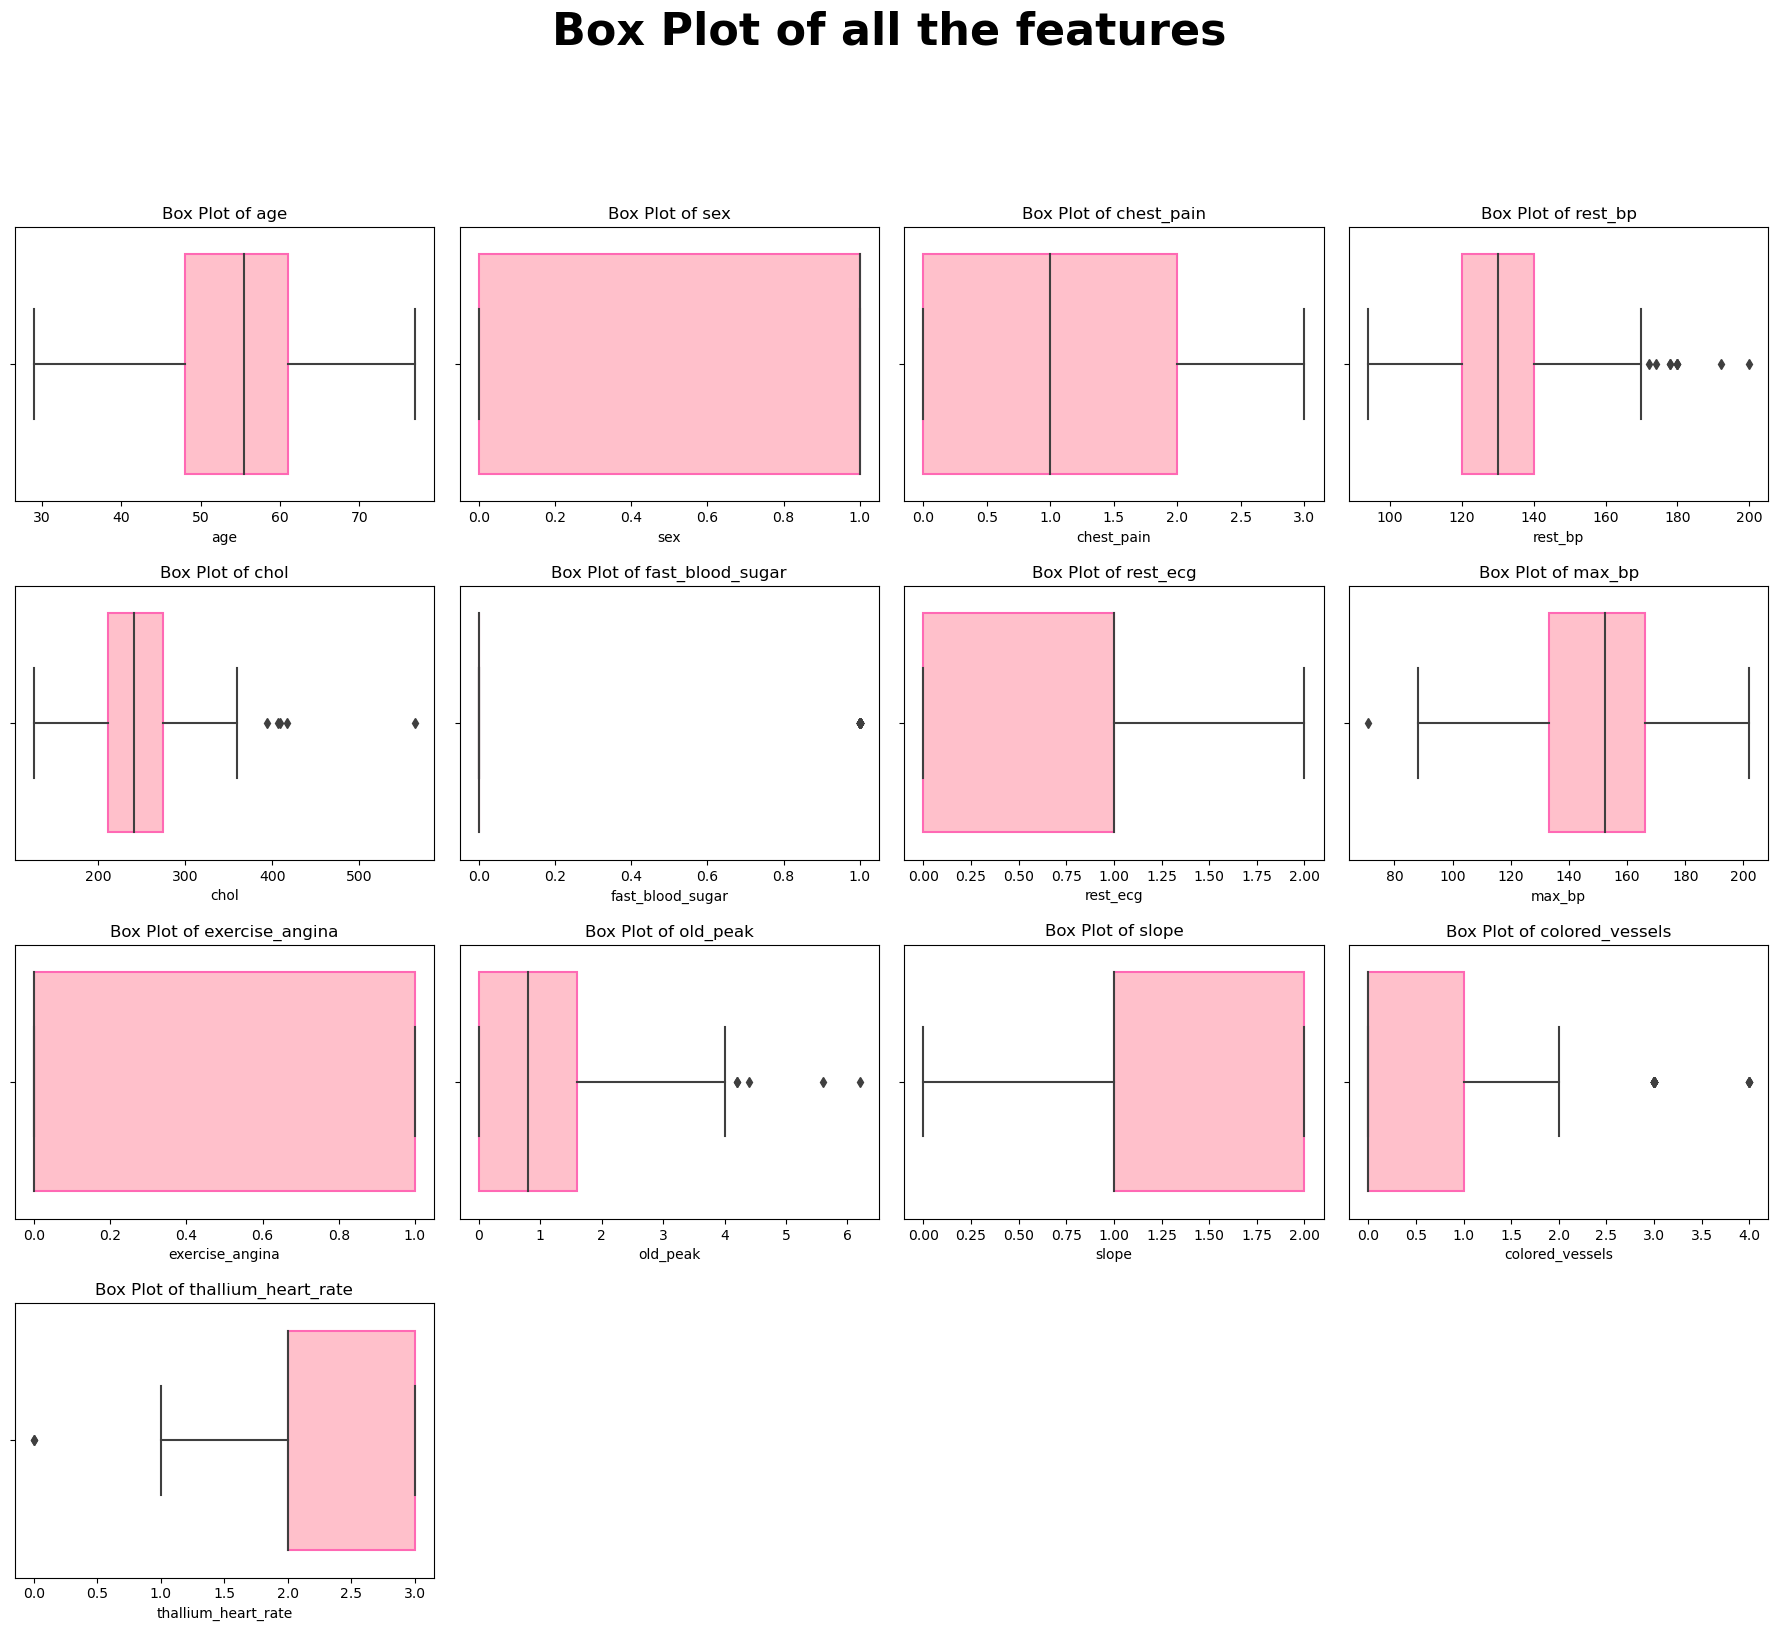

In [22]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.boxplot(data = X, x = feature, ax = ax[i], boxprops = dict(color = 'pink', edgecolor = 'hotpink'))
    ax[i].set_title(f"Box Plot of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

- Outliers are present in:
    - rest_bp
    - chol
    - fast_blood_sugar
    - max_bp
    - old_peak
    - colored_vessels
    - thallium_heart_rate

# Handling Outliers 

In [23]:
def replace_outliers_with_mean(df):
    
    for col in X.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mean_value = df[col].mean()
        
        # Replace outliers with mean
        df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), mean_value, df[col])
    
    return df

In [24]:
X = replace_outliers_with_mean(df)

# Box Plots after Outlier Handling

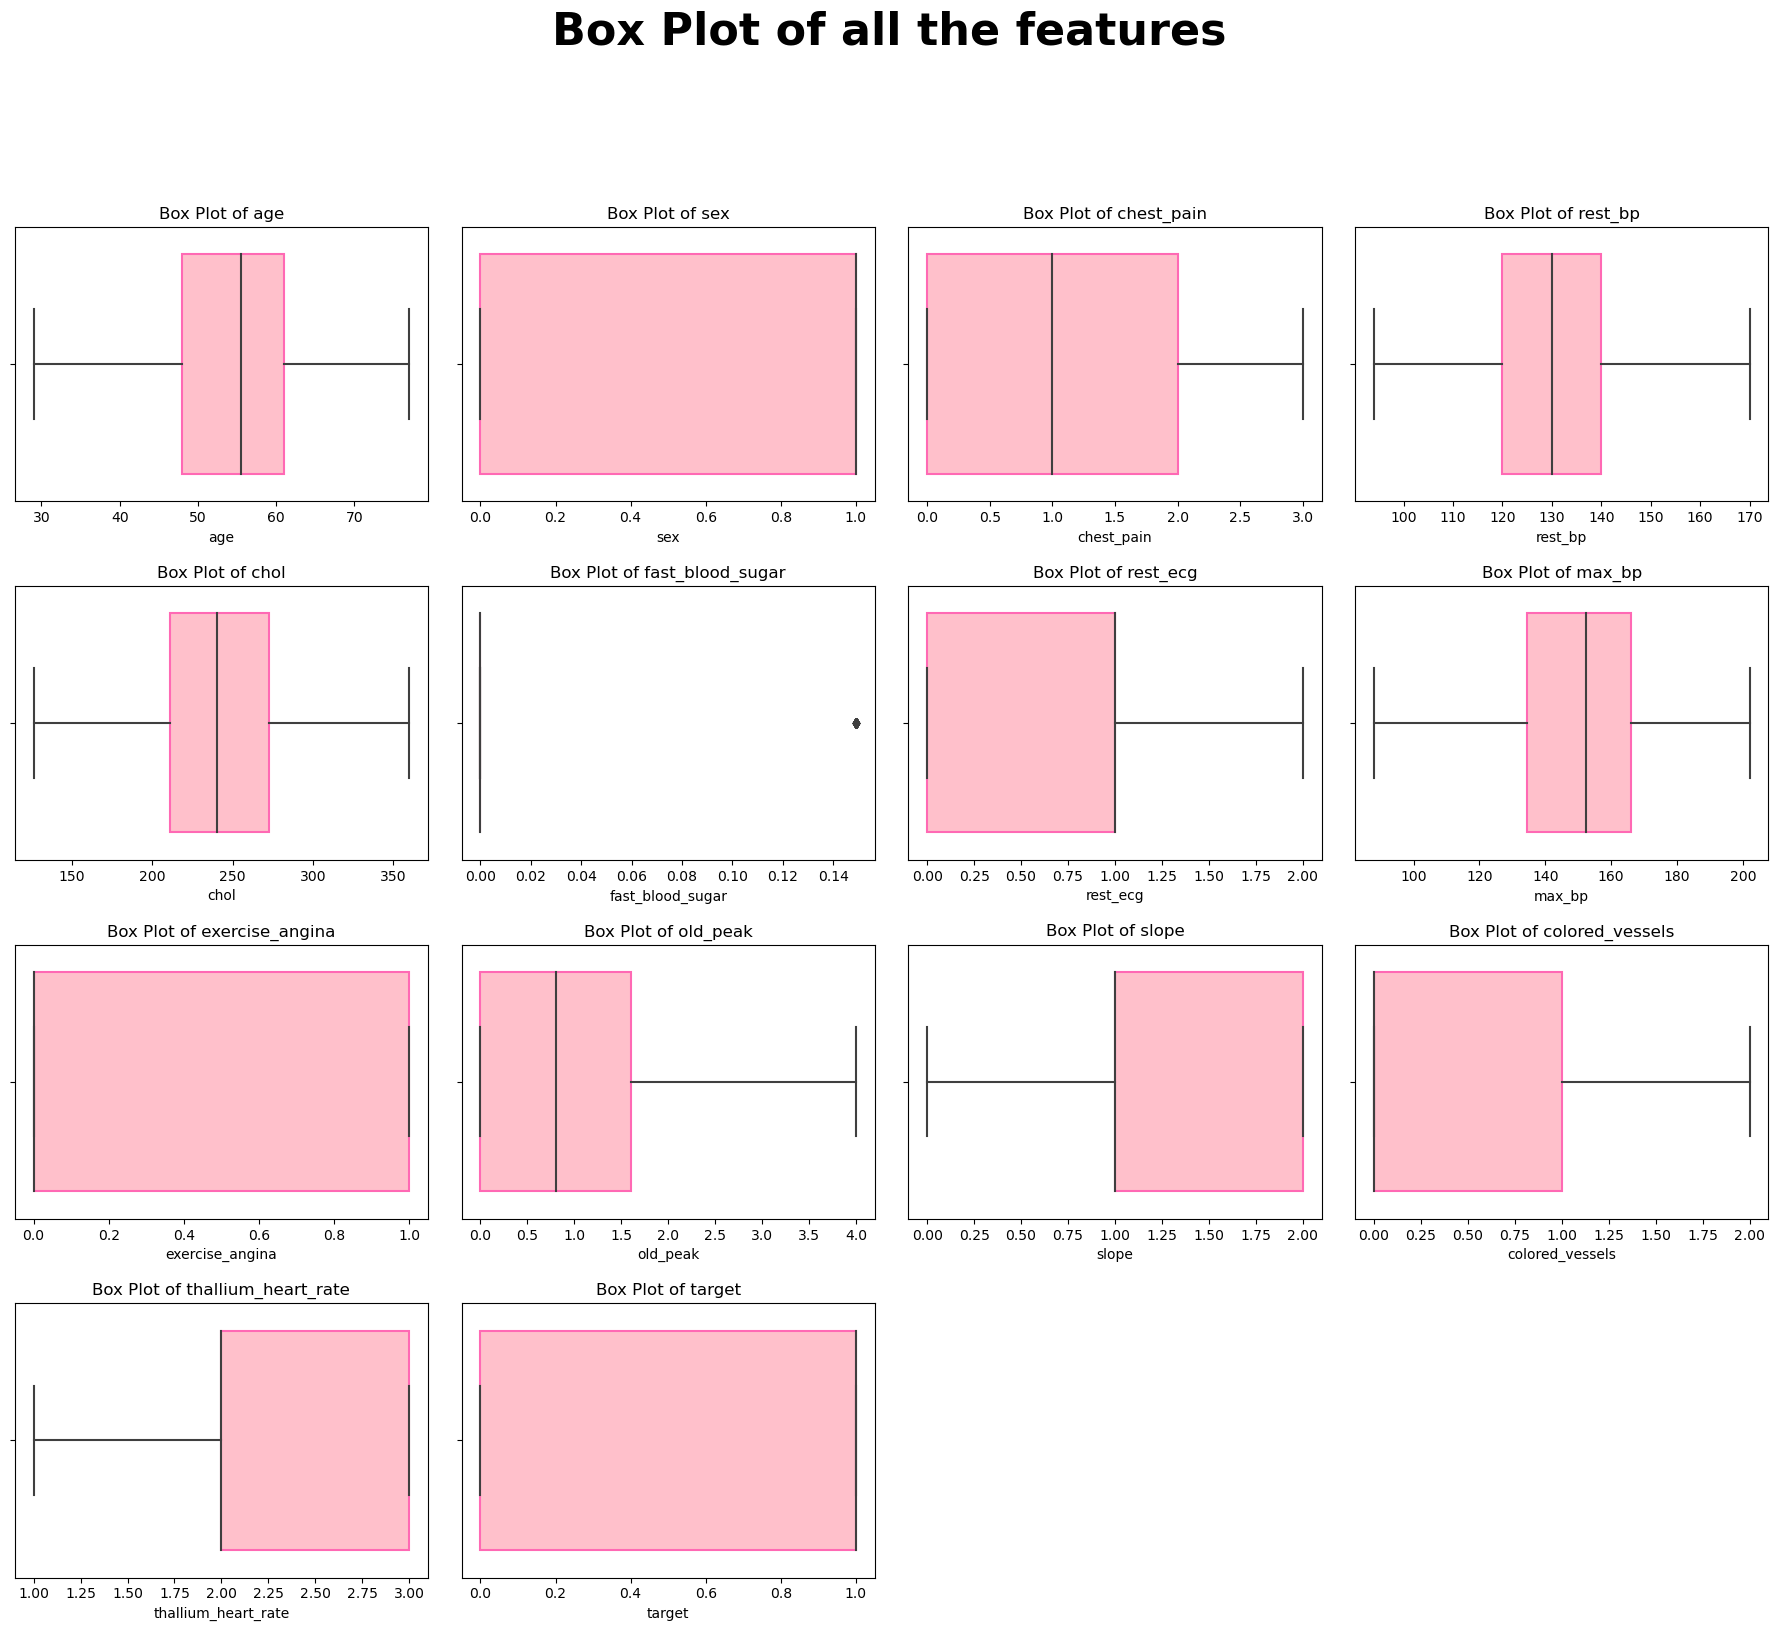

In [25]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.boxplot(data = X, x = feature, ax = ax[i], boxprops = dict(color = 'pink', edgecolor = 'hotpink'))
    ax[i].set_title(f"Box Plot of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

## Density Plots

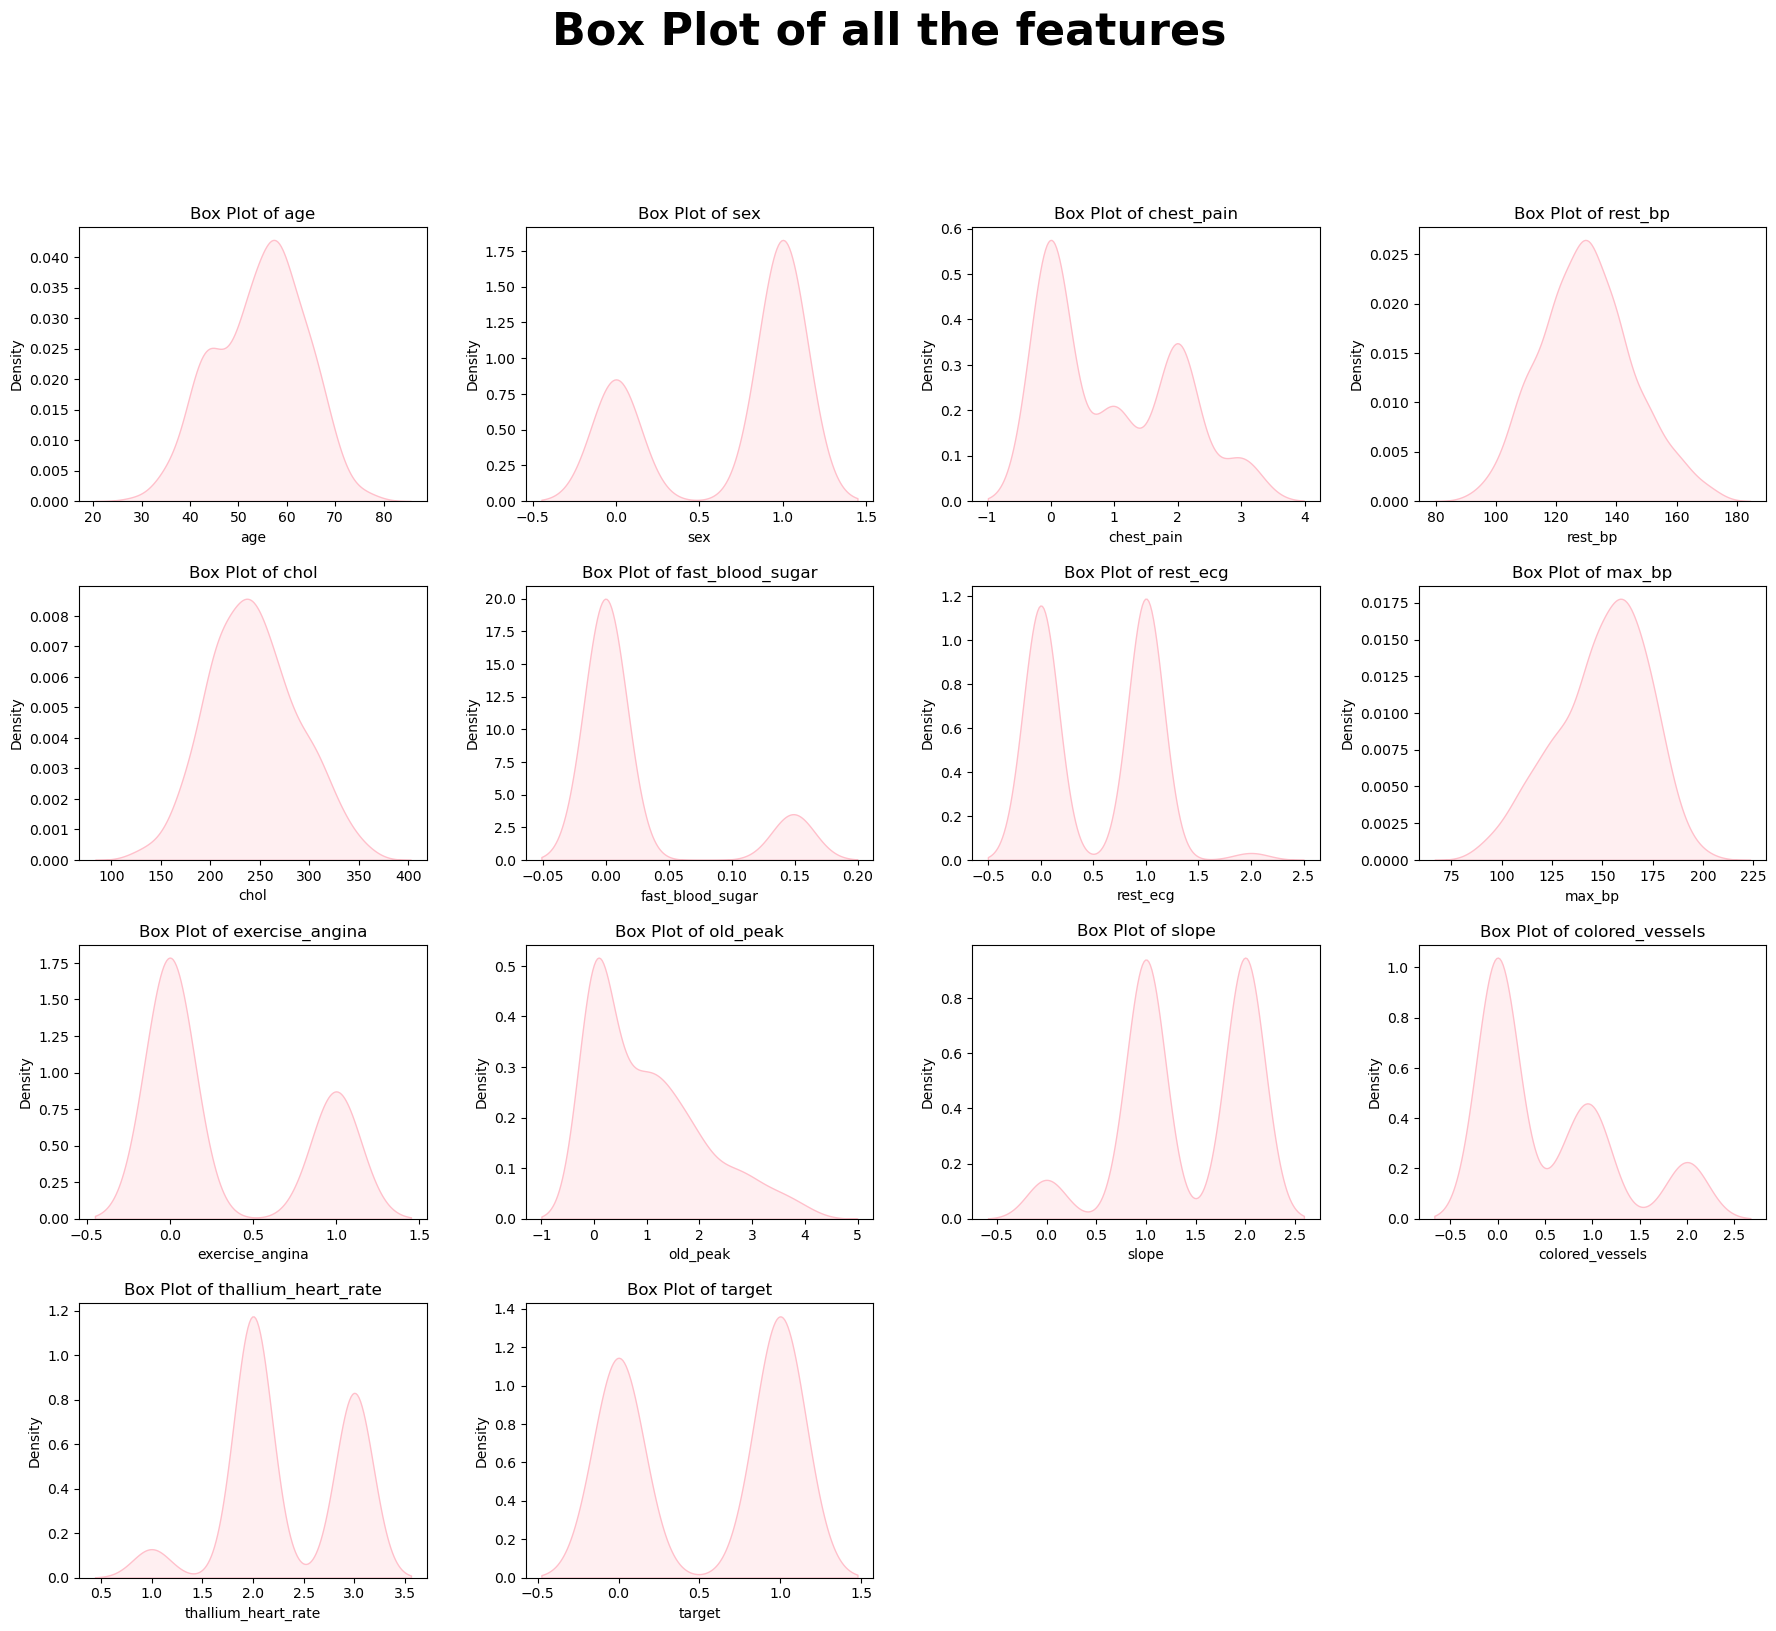

In [26]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.kdeplot(data = X, x = feature, ax = ax[i], color = 'pink', fill = 'brightpink')
    ax[i].set_title(f"Box Plot of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

- It explains the same as the Histogram plots

# Bivariate Analysis (Feature vs Target)

## Histograms 

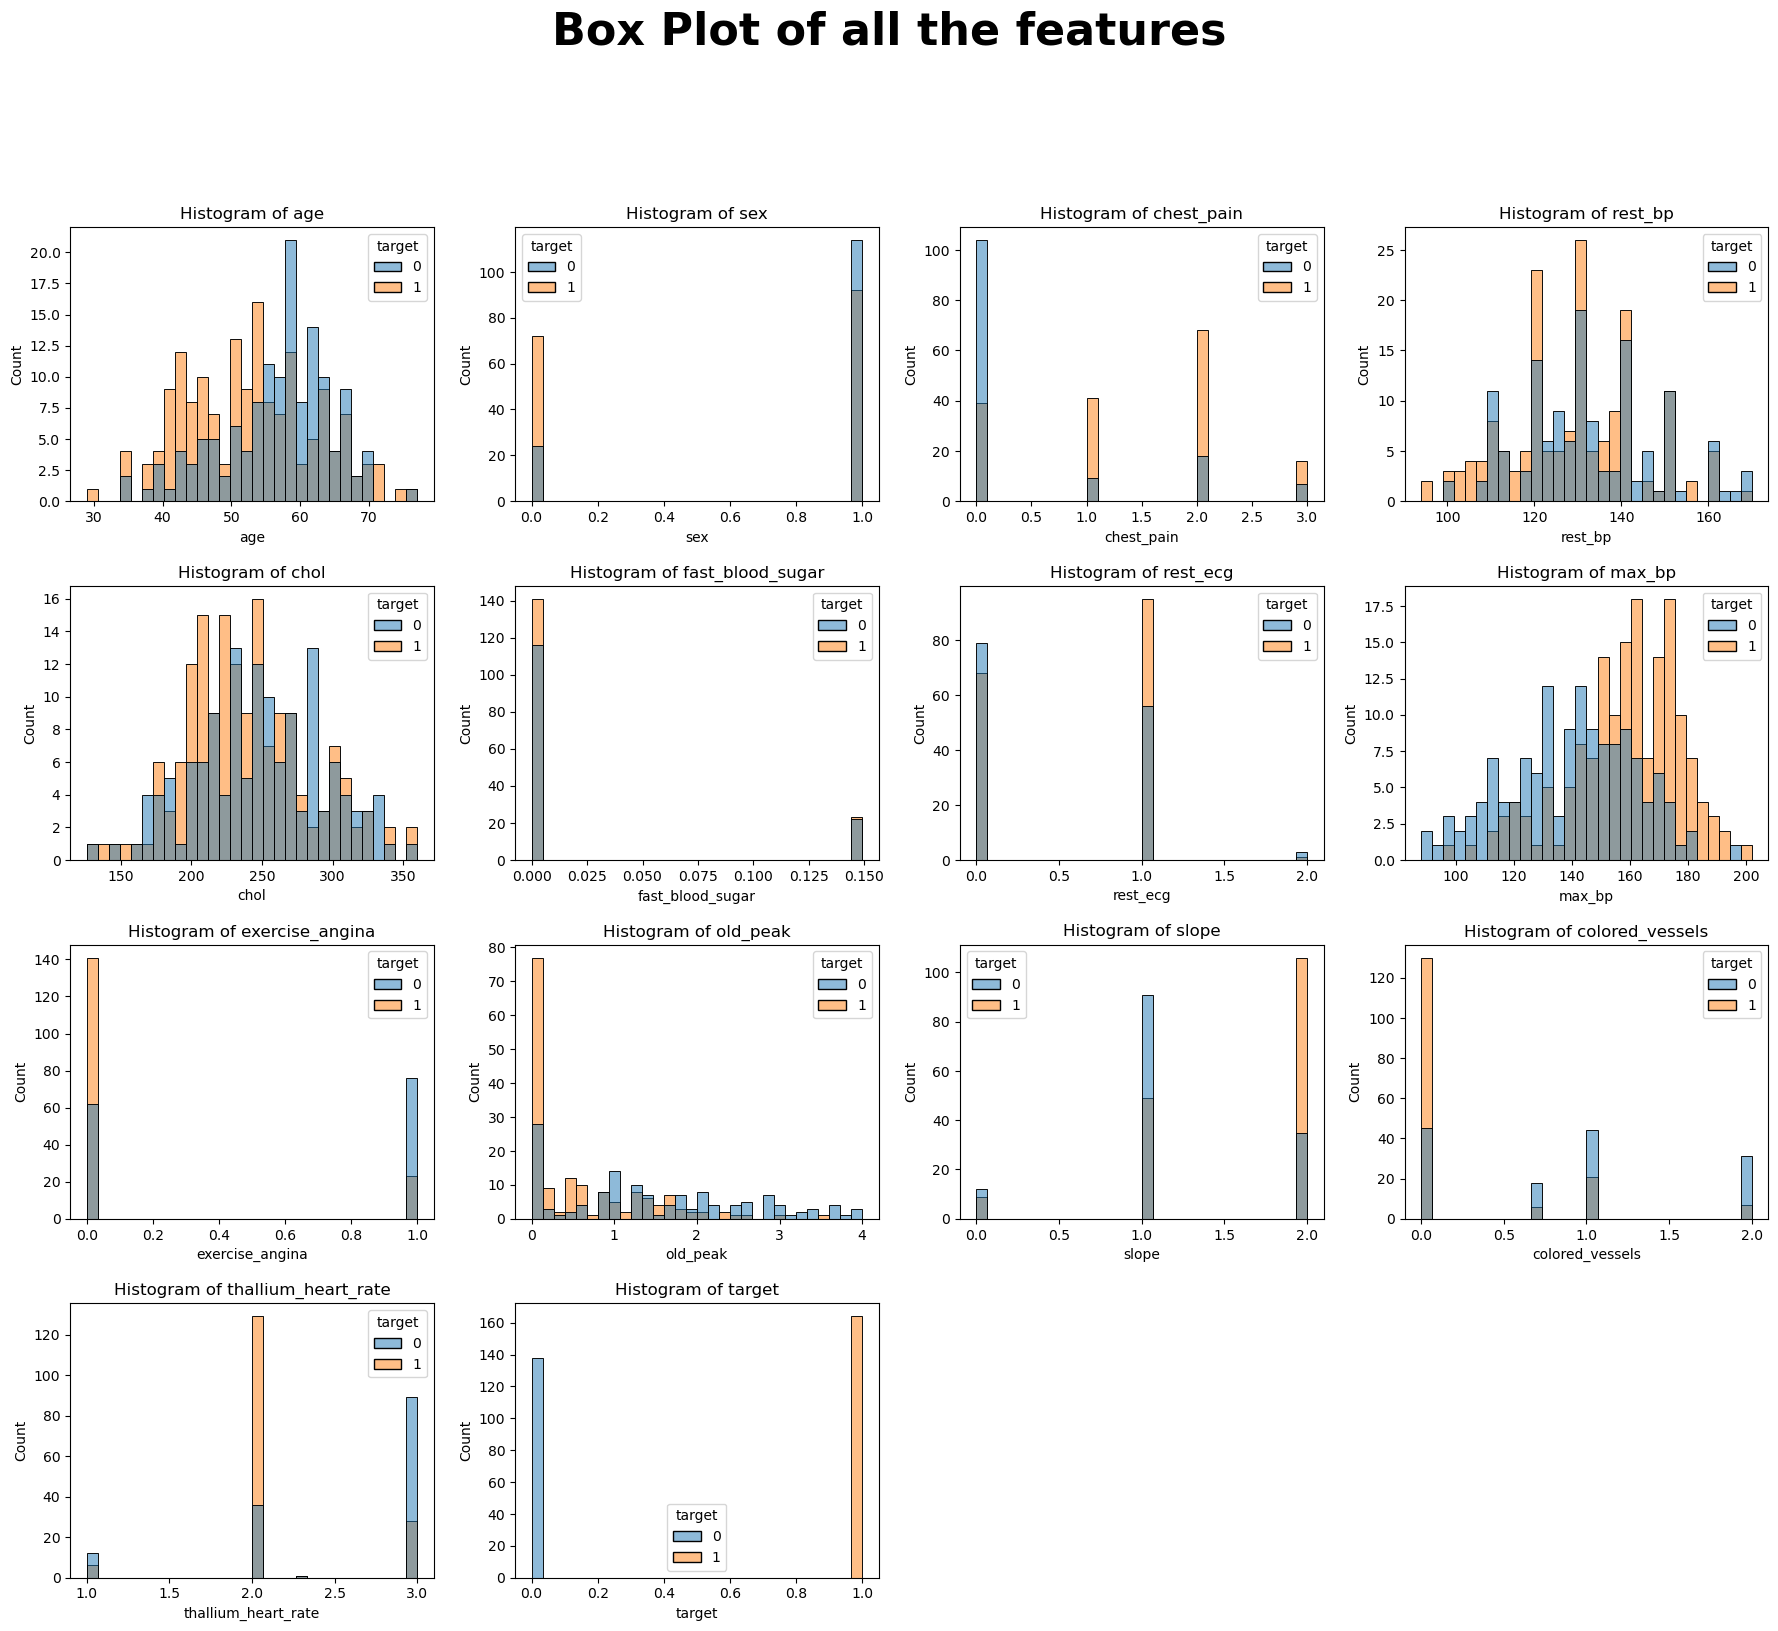

In [27]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.histplot(data = X, x = feature, ax = ax[i], hue = y['target'], bins = 30, kde = False, color = 'pink')
    ax[i].set_title(f"Histogram of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

- From the above plots, we can understand that:
    1. People of ages 30-55 have Heart Disease than others
    2. Females may or may not have higher chance of Heart Disease than men as ratio of female and male is different
    3. People with no Heart Disease have chest pain 0 on a scale of 0 to 3
    4. Resting state blood pressure is higher for people with heart diseases
    5. Cholestrol level is lower for people with heart disease which doesn't align so we might need more data to confirm
    6. Lower blood sugar level is observed for people with heart disease, which again might need more data to confirm
    7. rest ecg is 1 for heart disease patients 
    8. max_bp is higher for heart disease patients
    9. old_peak is 0 mostly for heart disease patients
    10. slope is 2.0 (higher) for heart disease patients

## Box Plots

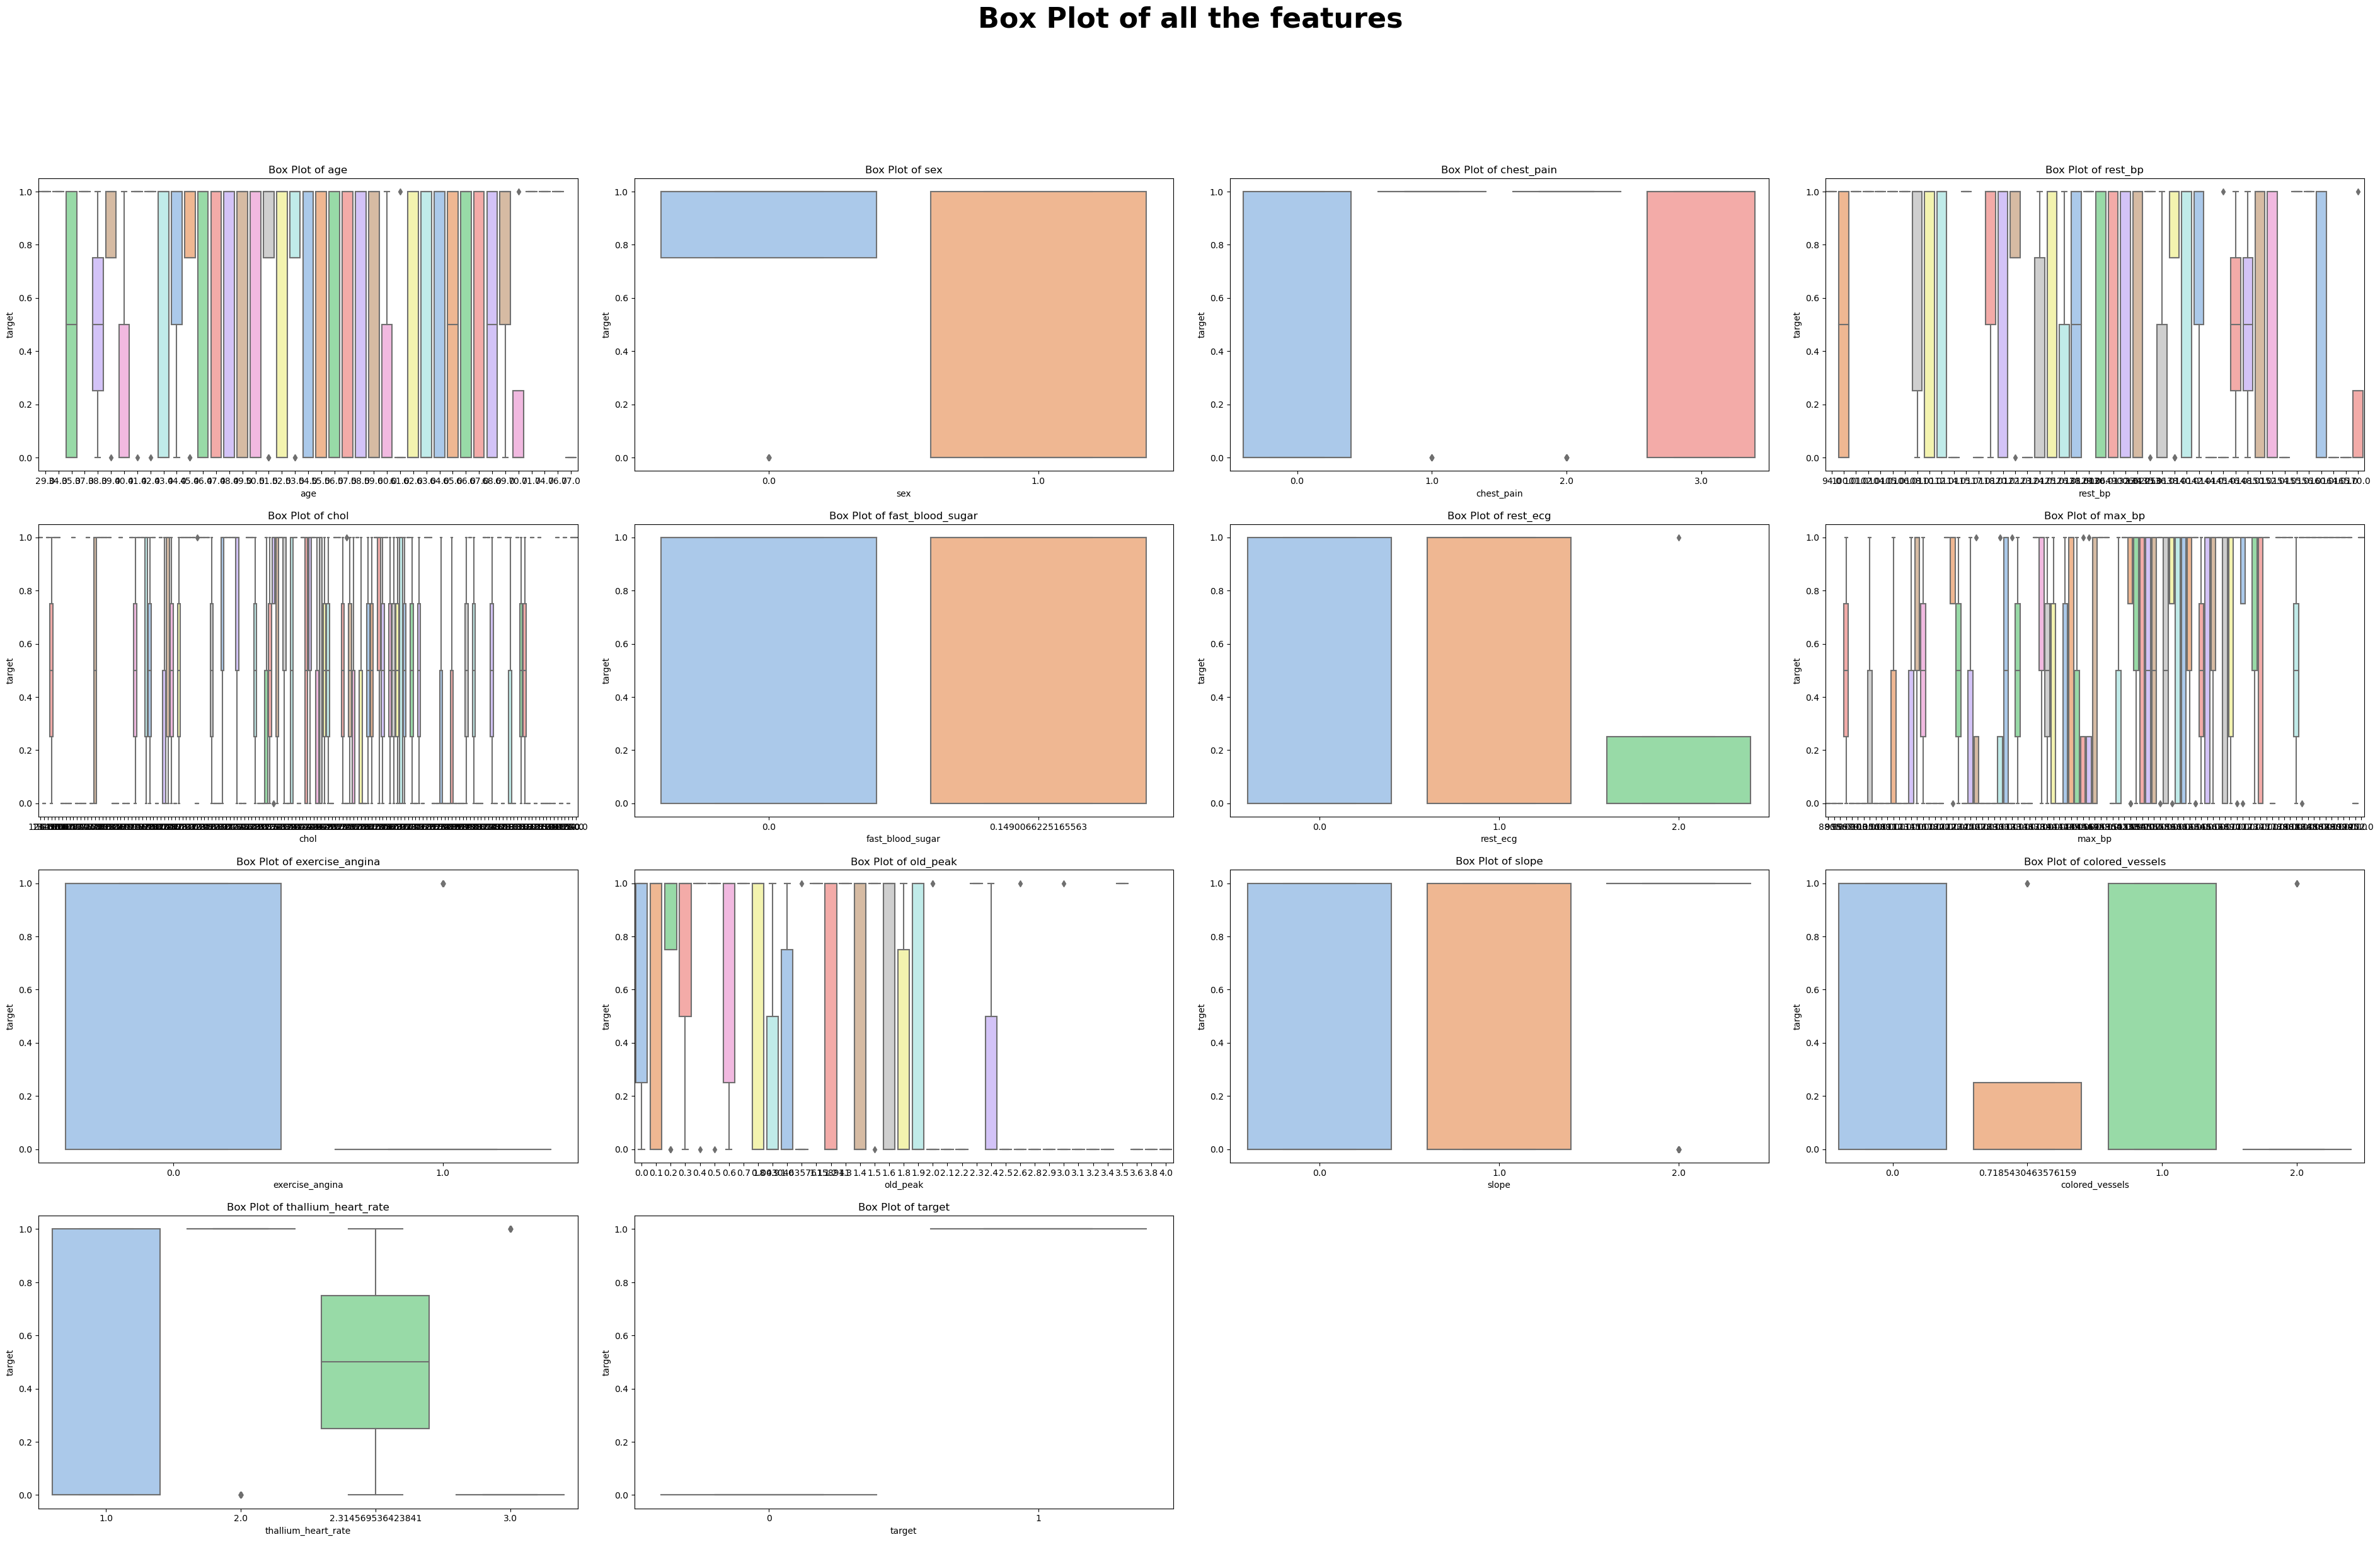

In [28]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(38,6*rows)) 

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.boxplot(data = X, x = feature, ax = ax[i], y = y['target'], palette = 'pastel')
    ax[i].set_title(f"Box Plot of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

- sex feature shows class imbalance as most Heart Disease Patients are shown as male
- old_peak and rest_bp show notable differences in distribution, suggesting they may be strong predictors.
- age, chol, and max_hr show overlapping but distinct spreads between classes, and may benefit from interaction terms or binning.
-  Features such as fast_blood_sugar and restecg show similar distributions for both target classes, suggesting limited predictive power.

## Density Plots 

C:\Users\HP\AppData\Local\Temp\ipykernel_28092\2870841375.py:10: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data = X, x = feature, ax = ax[i], hue = y['target'])


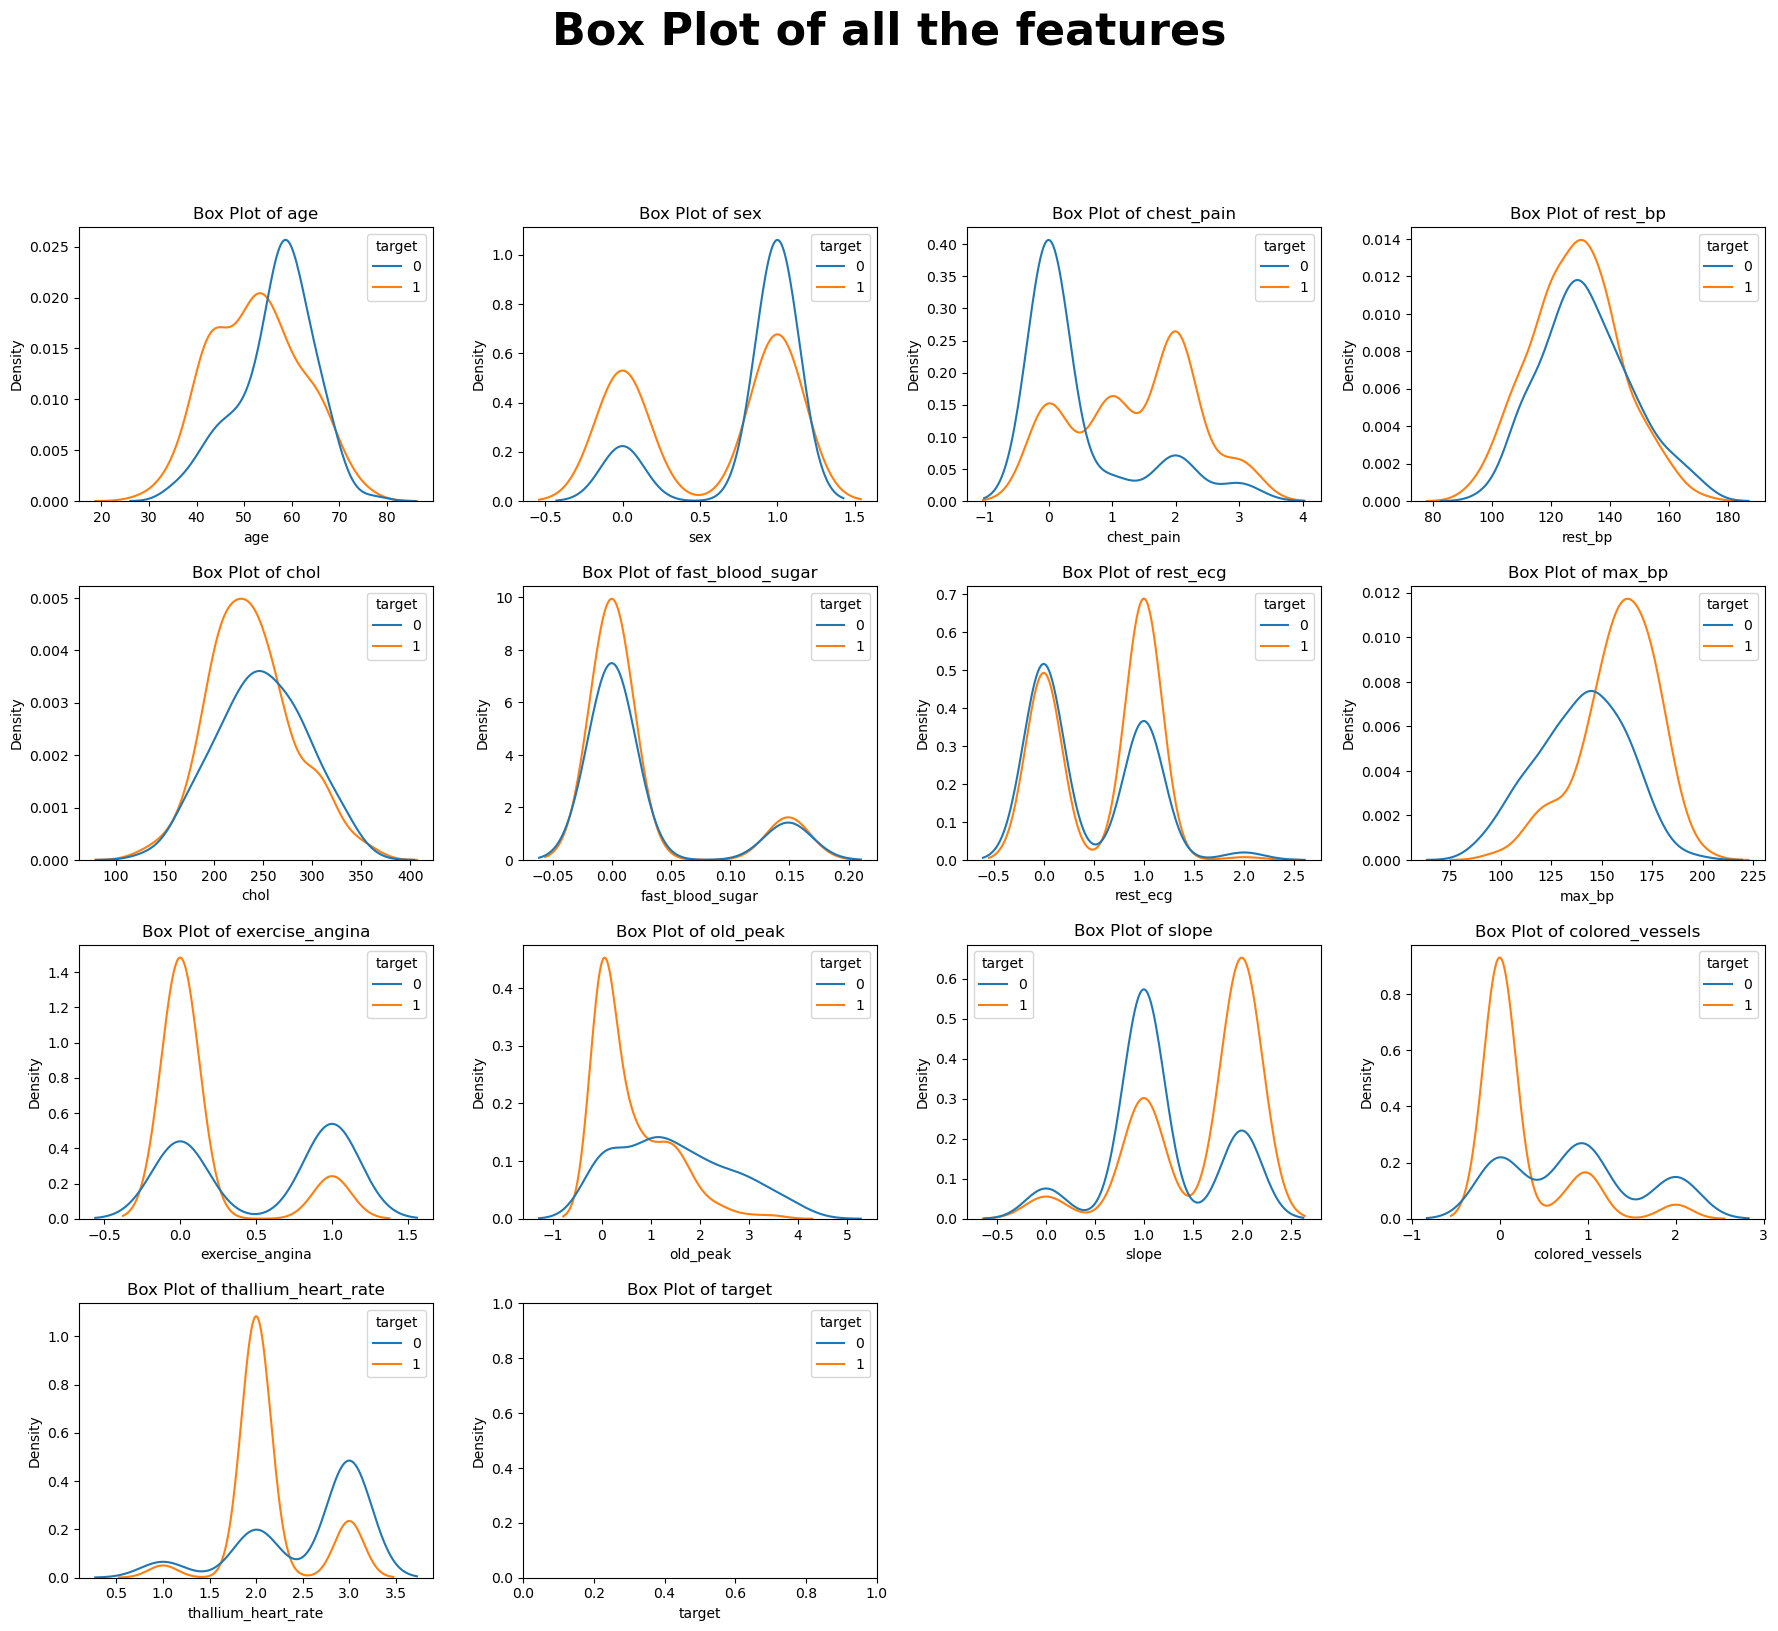

In [29]:
rows = math.ceil(len(X.columns)/4)

fig, ax = plt.subplots(rows, 4, figsize=(18,4*rows)) # 4 rows, 4 columns

fig.suptitle("Box Plot of all the features", fontsize = 32, weight = 'bold', y=1.02)

ax = ax.flatten()

for i, feature in enumerate(X):
    sns.kdeplot(data = X, x = feature, ax = ax[i], hue = y['target'])
    ax[i].set_title(f"Box Plot of {feature}")
    ax[i].set_xlabel(feature)
     
for j in range(i+1, len(ax)):
    ax[j].axis('off')


plt.tight_layout(pad = 1.5, rect = [0, 0, 1, 0.95])
plt.show()

- Same as the analysis from the Bivariate Histograms

## Scatter Plot

<Axes: xlabel='sex', ylabel='age'>

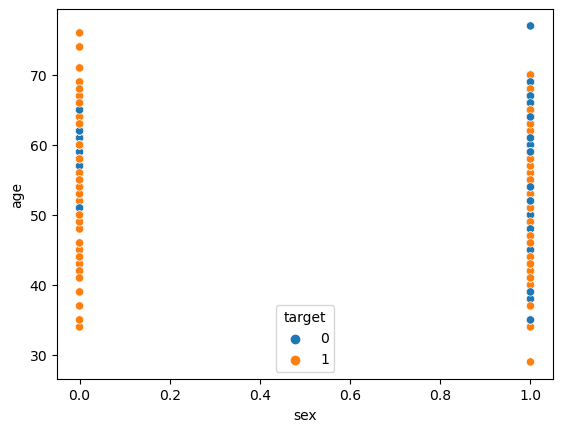

In [30]:
sns.scatterplot(x = df['sex'], y = df['age'], hue = df['target'], data=df)

- No clear analysis can be made from this 

# Multivariate Analysis 

## Correlation Heatmap

- To spot multi-collinearity

<Axes: >

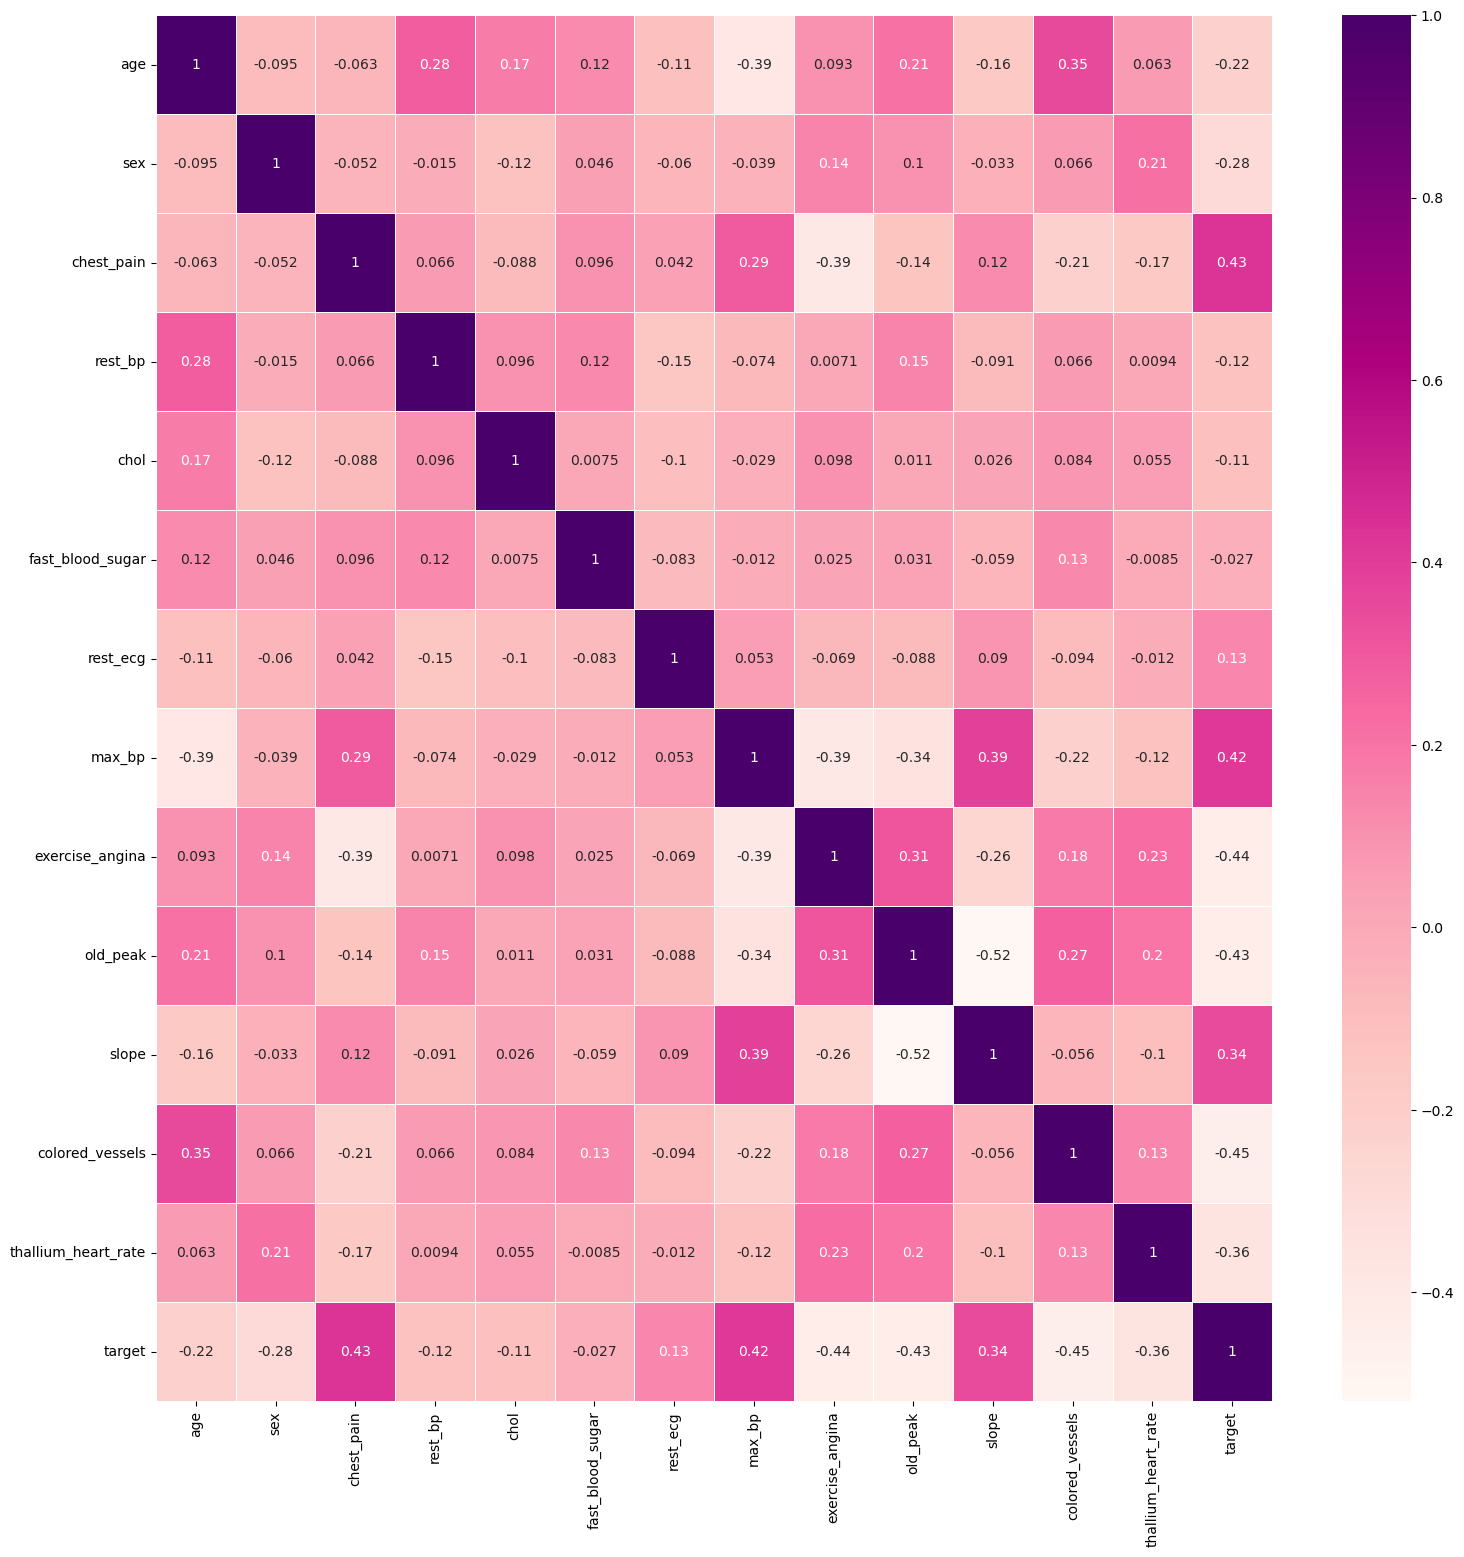

In [31]:
fig, ax = plt.subplots(figsize = (18, 18))

sns.heatmap(df.corr(), cmap = 'RdPu', annot = True, linewidth = .5, ax = ax)

- There is no high/moderate correlation between any features
- Thus, their is no multi-collinearity

## Variance Inflation Factor Computation

- VIF is a statistical measure used to quantify the severity of multicollinearity in regression analysis
- near 1: No Multi-collinearity
- above 10: Multi-collinearity exists

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x_vif = add_constant(df)

pd.Series([variance_inflation_factor(x_vif.values, i)
          for i in range(x_vif.shape[1])],
         index = x_vif.columns)

const                  250.497750
age                      1.470346
sex                      1.186972
chest_pain               1.395183
rest_bp                  1.149733
chol                     1.091148
fast_blood_sugar         1.064419
rest_ecg                 1.057405
max_bp                   1.611096
exercise_angina          1.461005
old_peak                 1.626467
slope                    1.561556
colored_vessels          1.462626
thallium_heart_rate      1.190241
target                   2.196649
dtype: float64

- There is no multi-collinearity between any of the features 

- Since, we've decided to go with tree based models, VIF or correlation heatmap isn't needed as decision trees splits on single features that improves accuracy, based on impurity measures like Gini or Entropy

# Splitting Data into Training and Testing Data

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [34]:
X_train.shape

(241, 14)

In [35]:
X_test.shape

(61, 14)

In [36]:
y_train.shape

(241, 1)

In [37]:
y_test.shape

(61, 1)

# Model Training

In [38]:
from sklearn.tree import DecisionTreeClassifier

model_decision_tree = DecisionTreeClassifier( criterion = 'gini', # gini is usulally faster than entropy
                                            splitter = 'best', # best gives optimal splits unlike random (imp for such medical data)
                                            max_depth = None, # We can observe overfitting if nay and then fine tune later 
                                            min_samples_split = 2, # Initially lets us learn in-depth, can increase later to reduce overfitting
                                            min_samples_leaf = 1, # Should start low to let the model capture edge cases, can tune later
                                            max_features = None, # Let model use all features first, later can use sqrt or log2
                                            random_state = 42)

model_decision_tree = model_decision_tree.fit(X_train, y_train)

y_pred_decision_tree = model_decision_tree.predict(X_test)

In [39]:
from sklearn.ensemble import RandomForestClassifier

model_random_forest = RandomForestClassifier(n_estimators = 100, # Number of trees in the forest100 gives good balance between accuracy & training time.
                                                                 # Can go higher for better stability
                                            criterion = 'gini',
                                            max_depth = None,
                                            min_samples_split = 2,
                                            min_samples_leaf = 1,
                                            max_features = 'sqrt', # Use √features per tree split,reduces variance for better generalization
                                            bootstrap = True, # Sampling with replacement, it's a Standard bagging mechanism
                                            oob_score = True,# Use out-of-bag samples to estimate performance
                                                             # Efficient cross-validation alternative in Random Forest
                                            random_state = 422,
                                            n_jobs = -1 # Use all available processors
                                                        # Great for speeding up training especially on large data
                                            )

model_random_forest = model_random_forest.fit(X_train, y_train)
y_pred_random_forest = model_random_forest.predict(X_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# Accuracy and Overfitting Analysis 

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Accuracy Scores 

In [41]:
dt_train_accuracy = model_decision_tree.score(X_train, y_train)
dt_test_accuracy = model_decision_tree.score(X_test, y_test)

In [42]:
rf_train_accuracy = model_random_forest.score(X_train, y_train)
rf_test_accuracy = model_random_forest.score(X_test, y_test)

In [43]:
accuracy_dict = { 'Model': ['Decision Tree', 'Random Forest'],
         'Training Accuracy': [dt_train_accuracy, rf_train_accuracy],
        ' Testing Accuracy': [dt_test_accuracy, rf_test_accuracy] }

In [44]:
accuracy_table = pd.DataFrame(data = accuracy_dict)

In [45]:
accuracy_table

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,1.0,1.0
1,Random Forest,1.0,1.0


## Classification Reports

In [46]:
print(classification_report(y_test, y_pred_decision_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        33

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



In [47]:
print(classification_report(y_test, y_pred_random_forest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        33

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



## Confusion Matrix

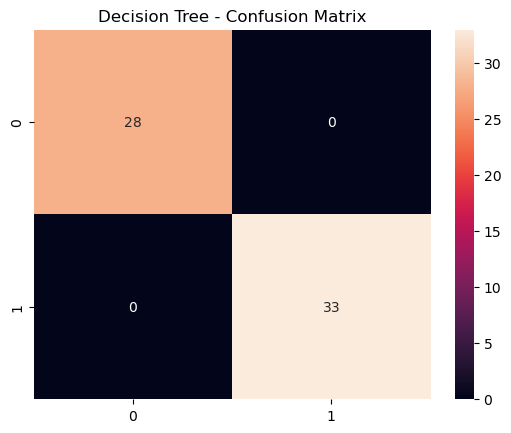

In [48]:
cm_dt = confusion_matrix(y_test, y_pred_decision_tree)

sns.heatmap(cm_dt, annot = True, fmt = 'd')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

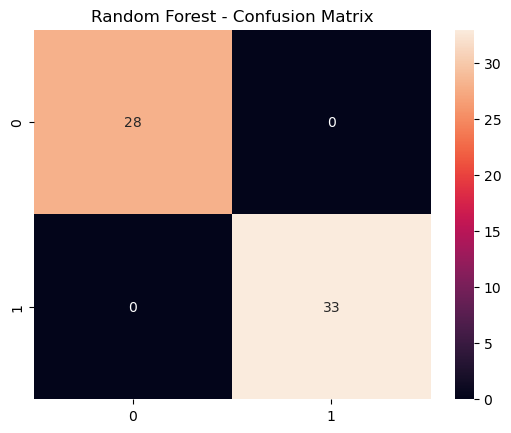

In [49]:
cm_rf = confusion_matrix(y_test, y_pred_random_forest)

sns.heatmap(cm_rf, annot = True, fmt = 'd')
plt.title("Random Forest - Confusion Matrix")
plt.show()

- From all the above accuracy scores, classification reports, and confusion matrix, we can observe the Random Forest performed better than Decision Trees.

# Feature Importances 

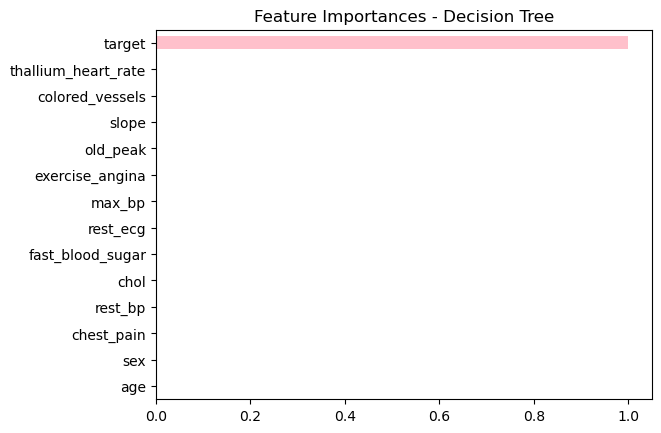

In [50]:
importances = model_decision_tree.feature_importances_

feature_importances_dt = pd.Series (importances, index = X.columns)

feature_importances_dt.sort_values().plot(kind='barh', color='pink')
plt.title("Feature Importances - Decision Tree")
plt.show()

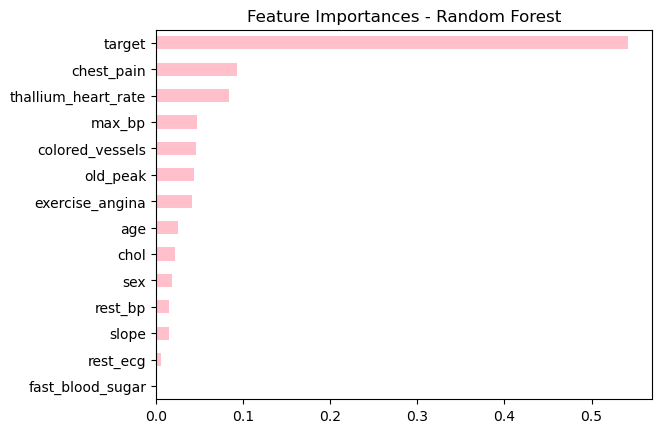

In [51]:
importances = model_random_forest.feature_importances_

feature_importances_rf = pd.Series (importances, index = X.columns)

feature_importances_rf.sort_values().plot(kind='barh', color='pink')
plt.title("Feature Importances - Random Forest")
plt.show()

- The order of feature Importances in Decision Trees and Random Forests in conflicting

# Cross Validation

In [52]:
from sklearn.model_selection import cross_val_score

CV_scores_DT = cross_val_score(model_decision_tree, X, y, cv=5, scoring='accuracy')

CV_DT_Mean_Accuracy = np.mean(CV_scores_DT)
CV_DT_Std_Dev =  np.std(CV_scores_DT)

CV_scores_DT

array([1., 1., 1., 1., 1.])

In [53]:
from sklearn.model_selection import cross_val_score

CV_scores_RF = cross_val_score(model_random_forest, X, y, cv=5, scoring='accuracy')

CV_RF_Mean_Accuracy = np.mean(CV_scores_RF)
CV_RF_Std_Dev =  np.std(CV_scores_RF)

CV_scores_RF

C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

array([1., 1., 1., 1., 1.])

In [54]:
CV_dict = {
    'Model': ['Decision Tree', 'Random Forest'],
    'CV_Mean_Accuracy': [CV_DT_Mean_Accuracy, CV_RF_Mean_Accuracy],
    'CV_Std_Dev': [CV_DT_Std_Dev, CV_RF_Std_Dev]
}

In [55]:
CV_table = pd.DataFrame(data = CV_dict)

In [56]:
CV_table

,Model,CV_Mean_Accuracy,CV_Std_Dev
0,Decision Tree,1.0,0.0
1,Random Forest,1.0,0.0


- The cross validation score is better for Random Forest model than the Decision Tree model

# Hyper-Parameter Tuning 

In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Accuracy:", grid_dt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 1.0


In [58]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    random_state=42
)

rand_rf.fit(X_train, y_train)

print("Best Parameters:", rand_rf.best_params_)
print("Best CV Accuracy:", rand_rf.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best CV Accuracy: 1.0


C:\Users\HP\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


- After fine tuning, the accuracy of Random Forest Model is still slightly better than the Decision Tree Model